# Scenario 2: Continuous — Default Reward
**Environment:** `MountainCarContinuous-v0`  
**Objective:** Reach the goal using as little energy as possible  
**Reward:** `-0.1 × action²` per step (action-cost penalty) + `+100` bonus when position ≥ 0.45  
**Algorithms:** PPO (Proximal Policy Optimisation) and SAC (Soft Actor-Critic) via Stable-Baselines3

## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import random
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns
import gymnasium as gym
import torch

from stable_baselines3 import PPO, SAC
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score

# ---------- print library versions ----------
import gymnasium as _gym, stable_baselines3 as _sb3, sklearn as _sk, matplotlib as _mpl, seaborn as _sns
print(f"gymnasium        : {_gym.__version__}")
print(f"stable-baselines3: {_sb3.__version__}")
print(f"numpy            : {np.__version__}")
print(f"matplotlib       : {_mpl.__version__}")
print(f"pandas           : {pd.__version__}")
print(f"scikit-learn     : {_sk.__version__}")
print(f"seaborn          : {_sns.__version__}")
print(f"torch            : {torch.__version__}")

# ---------- constants ----------
SEED        = 42
SCENARIO    = 2
GOAL_POS    = 0.45
RESULTS_DIR = '../results/scenario_2'
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---------- global seeds ----------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print(f"\nGlobal seed set to {SEED}. Results dir: {RESULTS_DIR}")

gymnasium        : 1.2.3
stable-baselines3: 2.8.0
numpy            : 2.4.3
matplotlib       : 3.10.8
pandas           : 3.0.1
scikit-learn     : 1.8.0
seaborn          : 0.13.2
torch            : 2.11.0+cpu

Global seed set to 42. Results dir: ../results/scenario_2


## 2. Environment

Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
  Low : [-1.2  -0.07]
  High: [0.6  0.07]
Action space:      Box(-1.0, 1.0, (1,), float32)
  Low : [-1.]
  High: [1.]


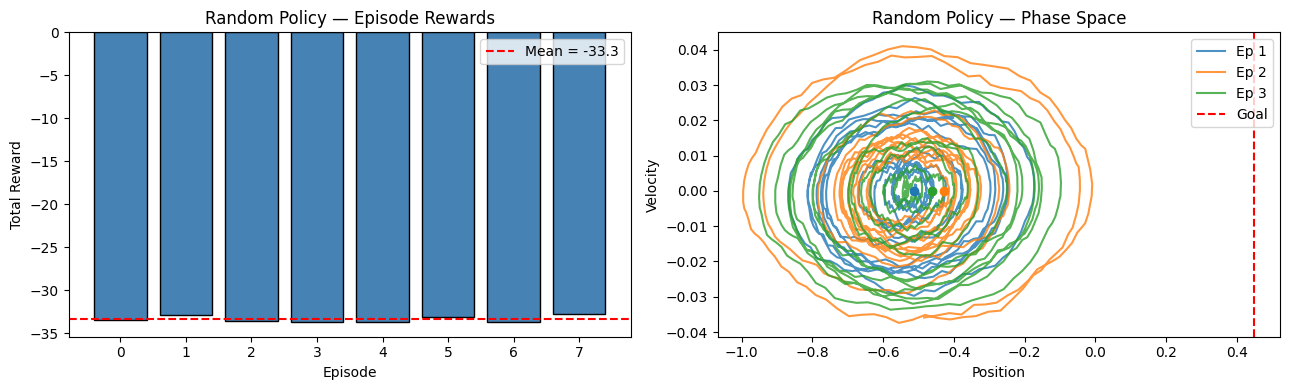

Random baseline — Mean: -33.33 ± 0.34


In [2]:
def make_env(seed=SEED):
    """Create a seeded, monitored MountainCarContinuous environment."""
    e = gym.make('MountainCarContinuous-v0')
    e = Monitor(e)
    e.reset(seed=seed)
    return e

env = make_env()
print(f'Observation space: {env.observation_space}')
print(f'  Low : {env.observation_space.low}')
print(f'  High: {env.observation_space.high}')
print(f'Action space:      {env.action_space}')
print(f'  Low : {env.action_space.low}')
print(f'  High: {env.action_space.high}')

# ---- random baseline: 8 episodes to establish baseline performance ----
N_RANDOM = 8
raw_env  = gym.make('MountainCarContinuous-v0')
raw_env.reset(seed=SEED)

random_rewards, sample_trajs = [], []
for ep in range(N_RANDOM):
    obs, _ = raw_env.reset()
    total_r, traj = 0.0, [obs.copy()]
    done = False
    while not done:
        action = raw_env.action_space.sample()
        obs, r, terminated, truncated, _ = raw_env.step(action)
        total_r += r
        traj.append(obs.copy())
        done = terminated or truncated
    random_rewards.append(total_r)
    if ep < 3:
        sample_trajs.append(np.array(traj))
raw_env.close()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(N_RANDOM), random_rewards, color='steelblue', edgecolor='black')
axes[0].axhline(np.mean(random_rewards), color='red', linestyle='--',
                label=f'Mean = {np.mean(random_rewards):.1f}')
axes[0].set_title('Random Policy — Episode Rewards')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Total Reward'); axes[0].legend()

for i, traj in enumerate(sample_trajs):
    c = ['tab:blue', 'tab:orange', 'tab:green'][i]
    axes[1].plot(traj[:, 0], traj[:, 1], color=c, alpha=0.8, label=f'Ep {i+1}')
    axes[1].scatter(traj[0, 0], traj[0, 1], color=c, marker='o', zorder=5)
axes[1].axvline(GOAL_POS, color='red', linestyle='--', label='Goal')
axes[1].set_title('Random Policy — Phase Space')
axes[1].set_xlabel('Position'); axes[1].set_ylabel('Velocity'); axes[1].legend()
plt.tight_layout(); plt.show()
print(f'Random baseline — Mean: {np.mean(random_rewards):.2f} ± {np.std(random_rewards):.2f}')

## 3. State & Action Representation

The state is a 2D continuous vector: **position** $p \in [-1.2,\; 0.6]$ and **velocity** $v \in [-0.07,\; 0.07]$. No discretisation or feature engineering is needed — both PPO and SAC accept the raw observation directly through an MLP policy head.

The action is a 1D continuous force $a \in [-1, 1]$, scaled internally by power $= 0.0015$. The transition dynamics are:

$$v_{t+1} = v_t + a_t \times 0.0015 - \cos(3 p_t) \times 0.0025, \qquad p_{t+1} = p_t + v_{t+1}$$

Both observations are already in a reasonable numeric range so no explicit normalisation is applied; SB3's MlpPolicy handles this adequately for this environment.

State space summary:
  Position : [-1.20, 0.60]
  Velocity : [-0.0700, 0.0700]

Action space: [-1.0, 1.0]  (scaled by power=0.0015 internally)


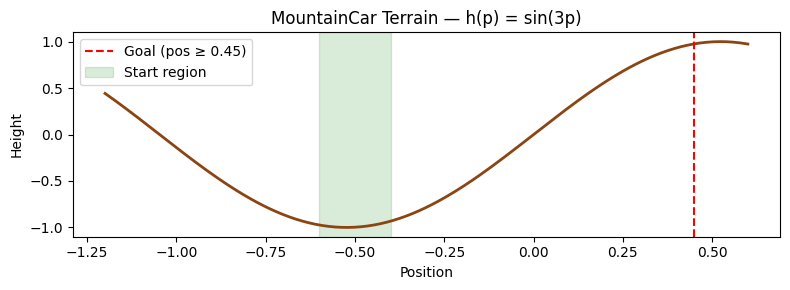

In [3]:
# No discretisation needed for continuous policy-gradient methods.
# Verify observation bounds directly from the environment.
obs_low  = env.observation_space.low
obs_high = env.observation_space.high
act_low  = env.action_space.low
act_high = env.action_space.high

print("State space summary:")
print(f"  Position : [{obs_low[0]:.2f}, {obs_high[0]:.2f}]")
print(f"  Velocity : [{obs_low[1]:.4f}, {obs_high[1]:.4f}]")
print(f"\nAction space: [{act_low[0]:.1f}, {act_high[0]:.1f}]  (scaled by power=0.0015 internally)")

# Visualise the terrain for physical context
pos_range = np.linspace(obs_low[0], obs_high[0], 300)
height    = np.sin(3 * pos_range)

plt.figure(figsize=(8, 3))
plt.plot(pos_range, height, color='saddlebrown', linewidth=2)
plt.axvline(GOAL_POS, color='red', linestyle='--', label=f'Goal (pos ≥ {GOAL_POS})')
plt.axvspan(-0.6, -0.4, alpha=0.15, color='green', label='Start region')
plt.title('MountainCar Terrain — h(p) = sin(3p)')
plt.xlabel('Position'); plt.ylabel('Height'); plt.legend()
plt.tight_layout(); plt.show()

## 4. Reward Design

The default reward in `MountainCarContinuous-v0` is:

$$r_t = -0.1 \cdot a_t^2 \qquad \text{(+100 bonus when } p_t \geq 0.45\text{)}$$

This is a **shaped reward** combining a dense action-cost signal with a sparse goal bonus. The squared penalty discourages bang-bang control — large constant forces are heavily penalised, pushing the agent toward gentle, well-timed pushes. This directly encodes the "minimum fuel" objective: reaching the goal matters, but *how* you get there also counts.

The key tension is that applying zero force avoids the penalty but never reaches the goal; the agent must find the minimum force trajectory that still consistently crosses the threshold.

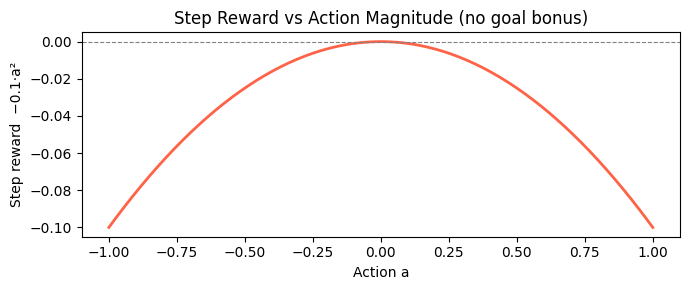

Example step rewards:
  a=+0.0  →  r = -0.0000  (+100 at goal → 100.0000)
  a=+0.5  →  r = -0.0250  (+100 at goal → 99.9750)
  a=+1.0  →  r = -0.1000  (+100 at goal → 99.9000)
  a=-1.0  →  r = -0.1000  (+100 at goal → 99.9000)


In [4]:
# Verify the reward function by manually computing it for a sample trajectory
def compute_reward(action, reached_goal):
    """Mirrors the MountainCarContinuous reward: -0.1*a^2, +100 at goal."""
    r = -0.1 * float(action) ** 2
    if reached_goal:
        r += 100.0
    return r

# Show reward as a function of action magnitude (no goal bonus)
actions = np.linspace(-1, 1, 200)
step_rewards = -0.1 * actions ** 2

plt.figure(figsize=(7, 3))
plt.plot(actions, step_rewards, color='tomato', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Step Reward vs Action Magnitude (no goal bonus)')
plt.xlabel('Action a'); plt.ylabel('Step reward  −0.1·a²')
plt.tight_layout(); plt.show()

print("Example step rewards:")
for a in [0.0, 0.5, 1.0, -1.0]:
    print(f"  a={a:+.1f}  →  r = {compute_reward(a, False):.4f}  "
          f"(+100 at goal → {compute_reward(a, True):.4f})")

## 5. Algorithm Selection & Hyperparameters

Tabular Q-learning (used in Scenario 1) cannot handle a continuous action space directly, so we need **policy-gradient methods** that output a distribution over $\mathbb{R}$.

- **PPO** (on-policy): clips policy updates to prevent destructive gradient steps — stable and robust across many continuous-action tasks. Simple to tune, no replay buffer needed.
- **SAC** (off-policy): maximises entropy alongside expected return, giving built-in exploration. Its replay buffer makes sample usage much more efficient, which can help in sparse-reward environments like this.

Both are instantiated with SB3's `MlpPolicy` (two hidden layers of 64 units by default). We train for **200 000 timesteps** each and evaluate every 10 000 steps using `evaluate_policy`.

In [5]:
TOTAL_TIMESTEPS = 300_000
EVAL_FREQ       = 10_000
N_EVAL_EPS      = 20

def periodic_eval(model, n_episodes=N_EVAL_EPS):
    """Quick evaluation helper — returns mean episode reward."""
    e = gym.make('MountainCarContinuous-v0')
    mean_r, _ = evaluate_policy(model, e, n_eval_episodes=n_episodes,
                                deterministic=True, warn=False)
    e.close()
    return mean_r

# --- PPO ---
# ent_coef=0.1 + use_sde prevents the zero-action local optimum trap
ppo_env = make_env(seed=SEED)
ppo_model = PPO(
    'MlpPolicy', ppo_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    ent_coef=0.1,
    use_sde=True,
    seed=SEED,
    verbose=0,
)

# --- SAC — SB3-Zoo recipe for MountainCarContinuous-v0 ---
# Key parameters: gamma=0.9999 (long-horizon sparse reward), large net,
# log_std_init=-3 keeps initial actions small but non-zero
sac_env = make_env(seed=SEED)
sac_model = SAC(
    'MlpPolicy', sac_env,
    learning_rate=7.3e-4,
    buffer_size=50_000,
    batch_size=256,
    ent_coef='auto',
    gamma=0.9999,          # near-1 discount essential for sparse +100 goal
    tau=0.02,
    train_freq=8,
    gradient_steps=8,
    learning_starts=10_000,
    use_sde=True,
    sde_sample_freq=4,
    policy_kwargs=dict(log_std_init=-3, net_arch=[400, 300]),
    seed=SEED,
    verbose=0,
)

print("PPO and SAC models ready.")
print(f"  PPO — ent_coef=0.1, use_sde=True")
print(f"  SAC — gamma=0.9999, use_sde=True, net_arch=[400,300], log_std_init=-3")

PPO and SAC models ready.
  PPO — ent_coef=0.1, use_sde=True
  SAC — gamma=0.9999, use_sde=True, net_arch=[400,300], log_std_init=-3


## 6. Training

Training PPO (ent_coef=0.1, use_sde=True) ...


  [  10000 steps]  PPO mean reward: -5.3


  [  60000 steps]  PPO mean reward: -94.8


  [ 110000 steps]  PPO mean reward: -99.9


  [ 160000 steps]  PPO mean reward: 87.0


...

  [ 110000 steps]  SAC mean reward: 95.8


  [ 160000 steps]  SAC mean reward: 96.2


  [ 210000 steps]  SAC mean reward: 96.2


  [ 260000 steps]  SAC mean reward: 96.5


SAC final mean reward: 96.23

[cache] Saved models + curves to ../results/scenario_2


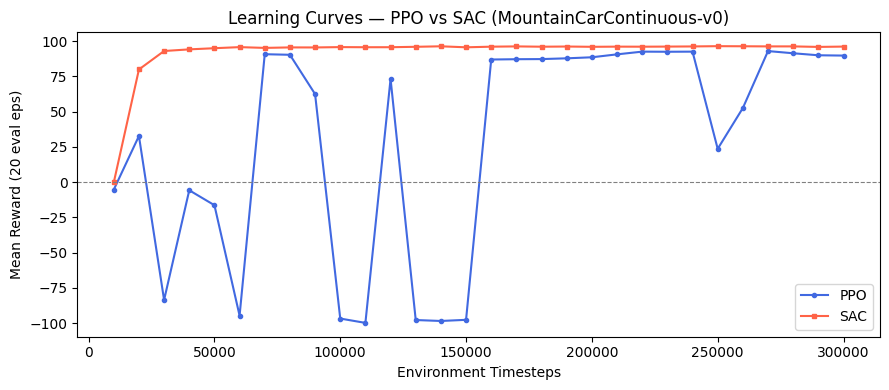


Better algorithm: SAC  (reward 96.2)


In [6]:
# Caching + training for PPO and SAC.
#
# Cache contract:
#   results/scenario_2/ppo_model.zip          (PPO weights)
#   results/scenario_2/sac_model.zip          (SAC weights)
#   results/scenario_2/training_curves.json   (periodic-eval rewards)
#
# If all three files exist we load them and skip training. Otherwise we
# train both algorithms from scratch (PPO first, then SAC), saving model
# zips and the curves JSON at the end. Delete any of the three files to
# force a retrain.

import json as _json
import os as _os

PPO_PATH    = _os.path.join(RESULTS_DIR, "ppo_model")
SAC_PATH    = _os.path.join(RESULTS_DIR, "sac_model")
CURVES_PATH = _os.path.join(RESULTS_DIR, "training_curves.json")

_cache_complete = (
    _os.path.exists(PPO_PATH + ".zip")
    and _os.path.exists(SAC_PATH + ".zip")
    and _os.path.exists(CURVES_PATH)
)

if _cache_complete:
    print(f"[cache] Loading PPO + SAC + curves from {RESULTS_DIR} (skipping training)")
    # Close the empty envs we built in cell 5 — we will not use them.
    for _e in (ppo_env, sac_env):
        try:
            _e.close()
        except Exception:
            pass
    ppo_model = PPO.load(PPO_PATH)
    sac_model = SAC.load(SAC_PATH)
    with open(CURVES_PATH) as _fh:
        _curves = _json.load(_fh)
    ppo_steps   = _curves["ppo_steps"]
    ppo_rewards = _curves["ppo_rewards"]
    sac_steps   = _curves["sac_steps"]
    sac_rewards = _curves["sac_rewards"]
    print(f"  PPO final mean reward: {ppo_rewards[-1]:.2f}")
    print(f"  SAC final mean reward: {sac_rewards[-1]:.2f}")
else:
    # ---- Train PPO ----
    # Reset global RNG so this branch is reproducible regardless of upstream cells.
    np.random.seed(SEED); torch.manual_seed(SEED); random.seed(SEED)
    ppo_steps, ppo_rewards = [], []
    print("Training PPO (ent_coef=0.1, use_sde=True) ...")
    for checkpoint in range(0, TOTAL_TIMESTEPS, EVAL_FREQ):
        ppo_model.learn(total_timesteps=EVAL_FREQ, reset_num_timesteps=False)
        mean_r = periodic_eval(ppo_model)
        ppo_steps.append(checkpoint + EVAL_FREQ)
        ppo_rewards.append(mean_r)
        if (checkpoint // EVAL_FREQ) % 5 == 0:
            print(f"  [{checkpoint + EVAL_FREQ:>7d} steps]  PPO mean reward: {mean_r:.1f}")
    ppo_env.close()
    ppo_model.save(PPO_PATH)
    print(f"PPO final mean reward: {ppo_rewards[-1]:.2f}")

    # ---- Train SAC ----
    # Reset global RNG again so SAC starts from a known state
    # (PPO's 300k steps would otherwise drain numpy/torch RNG and push
    # SAC into the do-nothing local optimum at the +100 sparse goal).
    np.random.seed(SEED); torch.manual_seed(SEED); random.seed(SEED)
    sac_steps, sac_rewards = [], []
    print("\nTraining SAC (SB3-Zoo hyperparameters) ...")
    for checkpoint in range(0, TOTAL_TIMESTEPS, EVAL_FREQ):
        sac_model.learn(total_timesteps=EVAL_FREQ, reset_num_timesteps=False)
        mean_r = periodic_eval(sac_model)
        sac_steps.append(checkpoint + EVAL_FREQ)
        sac_rewards.append(mean_r)
        if (checkpoint // EVAL_FREQ) % 5 == 0:
            print(f"  [{checkpoint + EVAL_FREQ:>7d} steps]  SAC mean reward: {mean_r:.1f}")
    sac_env.close()
    sac_model.save(SAC_PATH)
    print(f"SAC final mean reward: {sac_rewards[-1]:.2f}")

    # Persist curves so re-runs (with cached models) can still plot them.
    with open(CURVES_PATH, "w") as _fh:
        _json.dump({
            "ppo_steps":   ppo_steps,
            "ppo_rewards": ppo_rewards,
            "sac_steps":   sac_steps,
            "sac_rewards": sac_rewards,
        }, _fh)
    print(f"\n[cache] Saved models + curves to {RESULTS_DIR}")

# ---- Overlay learning curves ----
plt.figure(figsize=(9, 4))
plt.plot(ppo_steps, ppo_rewards, marker="o", markersize=3, color="royalblue", label="PPO")
plt.plot(sac_steps, sac_rewards, marker="s", markersize=3, color="tomato",    label="SAC")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.title("Learning Curves — PPO vs SAC (MountainCarContinuous-v0)")
plt.xlabel("Environment Timesteps"); plt.ylabel(f"Mean Reward ({N_EVAL_EPS} eval eps)")
plt.legend(); plt.tight_layout(); plt.show()

# Determine best algorithm
best_algo  = "PPO" if ppo_rewards[-1] >= sac_rewards[-1] else "SAC"
best_model = ppo_model if best_algo == "PPO" else sac_model
AlgoClass  = PPO       if best_algo == "PPO" else SAC
print(f"\nBetter algorithm: {best_algo}  (reward {max(ppo_rewards[-1], sac_rewards[-1]):.1f})")


## 7. Evaluation & Performance Metrics

Loaded SAC model from ../results/scenario_2/sac_model


  seed=0  Mean: 96.54  Std: 0.00  Success: 100%


  seed=42  Mean: 96.78  Std: 0.00  Success: 100%


  seed=123  Mean: 96.62  Std: 0.00  Success: 100%

--- Summary Table ---
 Seed  Mean Reward  Std Reward  Success Rate (%)
    0        96.54         0.0             100.0
   42        96.78         0.0             100.0
  123        96.62         0.0             100.0


C:\Users\minec\AppData\Local\Temp\ipykernel_9904\4061533813.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=box_data, x='Seed', y='Episode Reward', palette='pastel', ax=ax)


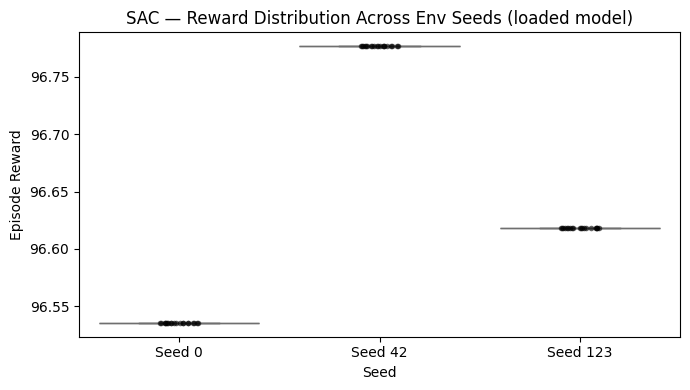

In [7]:
# Load the saved SAC model — no retraining
saved_model = SAC.load(os.path.join(RESULTS_DIR, 'sac_model'))
print(f"Loaded SAC model from {RESULTS_DIR}/sac_model")

# Evaluate with 3 different env reset seeds, 20 episodes each
EVAL_SEEDS   = [0, 42, 123]
N_EVAL_EPS   = 20
seed_summary = []
all_seed_rwds = {}

for seed in EVAL_SEEDS:
    ep_rwds, ep_success = [], []
    eval_env = gym.make('MountainCarContinuous-v0')

    for _ in range(N_EVAL_EPS):
        obs, _ = eval_env.reset(seed=seed)
        ep_r, reached = 0.0, False
        done = False
        while not done:
            action, _ = saved_model.predict(obs, deterministic=True)
            obs, r, t1, t2, _ = eval_env.step(action)
            ep_r += r
            if obs[0] >= GOAL_POS:
                reached = True
            done = t1 or t2
        ep_rwds.append(ep_r)
        ep_success.append(reached)

    eval_env.close()
    seed_summary.append({
        'Seed':             seed,
        'Mean Reward':      round(np.mean(ep_rwds), 2),
        'Std Reward':       round(np.std(ep_rwds),  2),
        'Success Rate (%)': round(np.mean(ep_success) * 100, 1),
    })
    all_seed_rwds[f'Seed {seed}'] = ep_rwds
    print(f"  seed={seed}  Mean: {np.mean(ep_rwds):.2f}  "
          f"Std: {np.std(ep_rwds):.2f}  "
          f"Success: {np.mean(ep_success)*100:.0f}%")

summary_df = pd.DataFrame(seed_summary)
print("\n--- Summary Table ---")
print(summary_df.to_string(index=False))

# Box plot
box_data = pd.DataFrame(all_seed_rwds).melt(var_name='Seed', value_name='Episode Reward')
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=box_data, x='Seed', y='Episode Reward', palette='pastel', ax=ax)
sns.stripplot(data=box_data, x='Seed', y='Episode Reward',
              color='black', size=4, alpha=0.6, jitter=True, ax=ax)
ax.set_title('SAC — Reward Distribution Across Env Seeds (loaded model)')
ax.set_ylabel('Episode Reward')
plt.tight_layout()
plt.show()

## 8. Policy Analysis

We analyse the learned policy from three angles:

1. **Action heatmap** — query the policy on a 50×50 grid over (position, velocity) and plot the output force. A diverging colourmap (blue = push left, red = push right) immediately reveals the momentum-building strategy.
2. **Phase portrait** — run several full episodes and plot trajectories in (position, velocity) space, showing the characteristic momentum-accumulation spiral.
3. **Value function** — evaluate the critic across the same state grid to see which states the agent considers "good" (high value = near-goal) vs "bad" (trapped in valley).

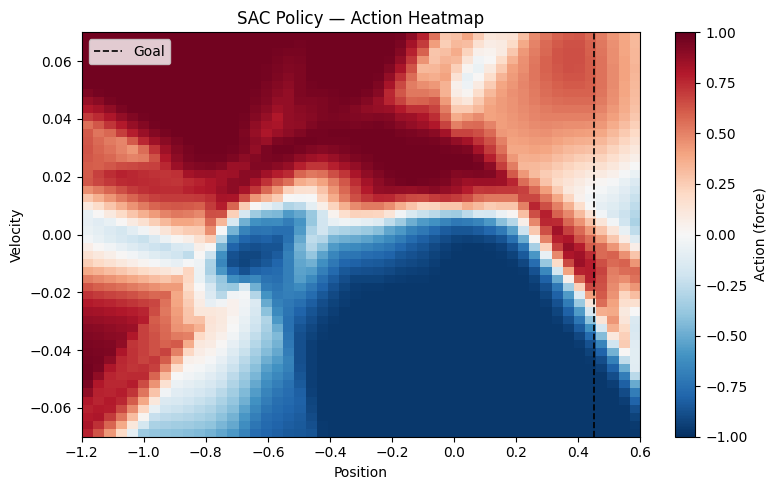

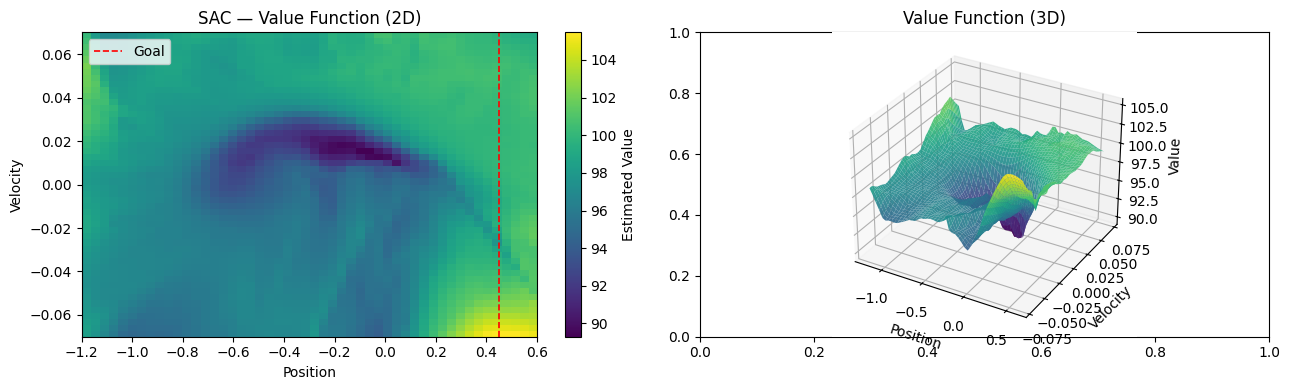

In [8]:
# ---- Policy heatmap ----
GRID_SIZE = 50
pos_lin = np.linspace(-1.2, 0.6,  GRID_SIZE)
vel_lin = np.linspace(-0.07, 0.07, GRID_SIZE)
pos_grid, vel_grid = np.meshgrid(pos_lin, vel_lin)
grid_obs = np.column_stack([pos_grid.ravel(), vel_grid.ravel()])

# Query policy at every grid point
actions_flat = np.array([best_model.predict(o, deterministic=True)[0][0] for o in grid_obs])
action_map   = actions_flat.reshape(GRID_SIZE, GRID_SIZE)

plt.figure(figsize=(8, 5))
plt.imshow(action_map, extent=[-1.2, 0.6, -0.07, 0.07],
           origin='lower', aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Action (force)')
plt.axvline(GOAL_POS, color='black', linestyle='--', linewidth=1.2, label='Goal')
plt.title(f'{best_algo} Policy — Action Heatmap')
plt.xlabel('Position'); plt.ylabel('Velocity'); plt.legend()
plt.tight_layout(); plt.show()

# ---- Value function heatmap ----
import torch as th

obs_t = th.FloatTensor(grid_obs).to(best_model.device)
with th.no_grad():
    if best_algo == 'SAC':
        acts_t = best_model.actor(obs_t)
        if isinstance(acts_t, tuple): acts_t = acts_t[0]
        q1, q2 = best_model.critic(obs_t, acts_t)
        values = th.min(q1, q2).cpu().numpy().squeeze()
    else:
        values = best_model.policy.predict_values(obs_t).cpu().numpy().squeeze()

value_map = values.reshape(GRID_SIZE, GRID_SIZE)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
im = axes[0].imshow(value_map, extent=[-1.2, 0.6, -0.07, 0.07],
                    origin='lower', aspect='auto', cmap='viridis')
fig.colorbar(im, ax=axes[0], label='Estimated Value')
axes[0].axvline(GOAL_POS, color='red', linestyle='--', linewidth=1.2, label='Goal')
axes[0].set_title(f'{best_algo} — Value Function (2D)'); axes[0].set_xlabel('Position')
axes[0].set_ylabel('Velocity'); axes[0].legend()

from mpl_toolkits.mplot3d import Axes3D  # noqa
ax3 = fig.add_subplot(122, projection='3d')
ax3.plot_surface(pos_grid, vel_grid, value_map, cmap='viridis', edgecolor='none', alpha=0.9)
ax3.set_xlabel('Position'); ax3.set_ylabel('Velocity'); ax3.set_zlabel('Value')
ax3.set_title('Value Function (3D)')
plt.tight_layout(); plt.show()

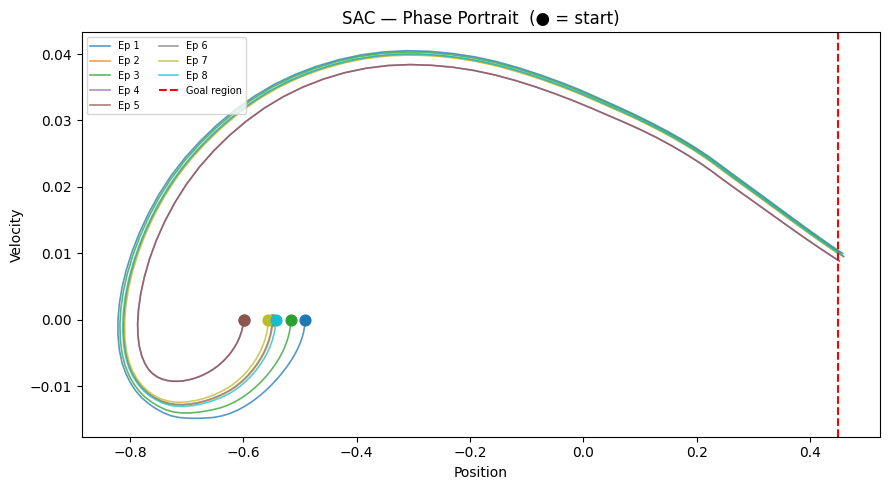


--- Reward Decomposition (20 test episodes) ---


 Episode  Goal Reached  Eng. Reward  Fuel Σa²
       1          True        95.27   47.2934
       2          True        96.74   32.5899
       3          True        95.55   44.4611
       4          True        95.33   46.6800
       5          True        96.05   39.4891
       6          True        96.97   30.3423
       7          True        95.43   45.6911
       8          True        96.17   38.2536
       9          True        96.94   30.5551
      10          True        96.63   33.7156
      11          True        96.67   33.2999
      12          True        95.27   47.3115
      13          True        95.24   47.6107
      14          True        96.56   34.3529
      15          True        96.60   34.0327
      16          True        95.43   45.6703
      17          True        95.52   44.8491
      18          True        95.58   44.1731
      19          True        96.16   38.3829
      20          True        95.83   41.6857

Success rate : 100%
Mean reward  

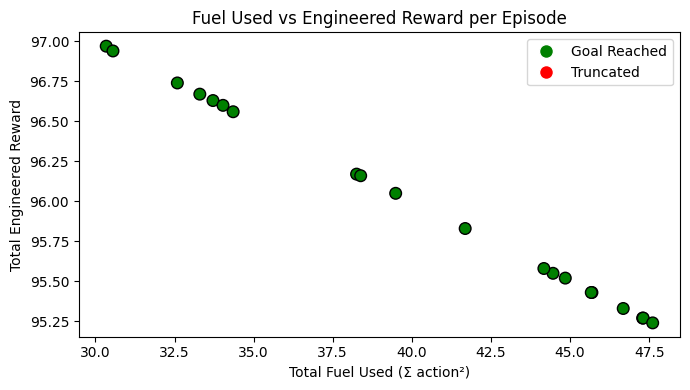

In [9]:
# ---- Phase portrait: trajectories of trained agent episodes ----
N_TRAJ   = 8
traj_env = gym.make('MountainCarContinuous-v0')
palette  = cm.get_cmap('tab10', N_TRAJ)

fig, ax = plt.subplots(figsize=(9, 5))
for ep in range(N_TRAJ):
    obs, _ = traj_env.reset()
    pos_hist, vel_hist = [obs[0]], [obs[1]]
    done = False
    while not done:
        action, _ = best_model.predict(obs, deterministic=True)
        obs, _, t1, t2, _ = traj_env.step(action)
        pos_hist.append(obs[0]); vel_hist.append(obs[1])
        done = t1 or t2
    color = palette(ep)
    ax.plot(pos_hist, vel_hist, color=color, alpha=0.75, linewidth=1.2, label=f'Ep {ep+1}')
    ax.scatter(pos_hist[0], vel_hist[0], color=color, marker='o', s=60, zorder=5)
traj_env.close()

ax.axvline(GOAL_POS, color='red', linestyle='--', linewidth=1.5, label='Goal region')
ax.set_xlabel('Position'); ax.set_ylabel('Velocity')
ax.set_title(f'{best_algo} — Phase Portrait  (● = start)')
ax.legend(loc='upper left', fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

# ---- Reward decomposition: objective vs engineered ----
print("\n--- Reward Decomposition (20 test episodes) ---")
test_env = gym.make('MountainCarContinuous-v0')
test_rows = []
for ep in range(N_EVAL_EPS):
    obs, _ = test_env.reset()
    eng_r, fuel, reached = 0.0, 0.0, False
    done = False
    while not done:
        action, _ = best_model.predict(obs, deterministic=True)
        obs, r, t1, t2, _ = test_env.step(action)
        eng_r += r; fuel += float(action[0] ** 2)
        if obs[0] >= GOAL_POS: reached = True
        done = t1 or t2
    test_rows.append({'Episode': ep+1, 'Goal Reached': reached,
                      'Eng. Reward': round(eng_r, 2), 'Fuel Σa²': round(fuel, 4)})
test_env.close()
test_df = pd.DataFrame(test_rows)
print(test_df.to_string(index=False))
print(f"\nSuccess rate : {test_df['Goal Reached'].mean()*100:.0f}%")
print(f"Mean reward  : {test_df['Eng. Reward'].mean():.2f}")
print(f"Mean fuel    : {test_df['Fuel Σa²'].mean():.4f}")

from matplotlib.lines import Line2D
fig2, ax2 = plt.subplots(figsize=(7, 4))
colors = test_df['Goal Reached'].map({True: 'green', False: 'red'})
ax2.scatter(test_df['Fuel Σa²'], test_df['Eng. Reward'], c=colors, edgecolors='black', s=70)
legend_els = [Line2D([0],[0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Goal Reached'),
              Line2D([0],[0], marker='o', color='w', markerfacecolor='red',   markersize=10, label='Truncated')]
ax2.legend(handles=legend_els)
ax2.set_xlabel('Total Fuel Used (Σ action²)'); ax2.set_ylabel('Total Engineered Reward')
ax2.set_title('Fuel Used vs Engineered Reward per Episode')
plt.tight_layout(); plt.show()

## 9. Interpretability

Neural network policies are black boxes. To get an interpretable proxy we fit a shallow **decision tree** (max depth 5) to the policy's input-output mapping — the same 50×50 state grid used for the heatmap. We then inspect feature importances to answer: does the agent primarily react to *where* it is (position) or *how fast* it is moving (velocity)?

From the physics of the problem we expect **velocity** to dominate: the resonance strategy is "push in the direction of current motion", which is encoded entirely in the velocity sign. Position matters mainly near the goal region.

Decision tree R² vs neural policy : 0.9299
Feature importances — Position: 0.3006  |  Velocity: 0.6994


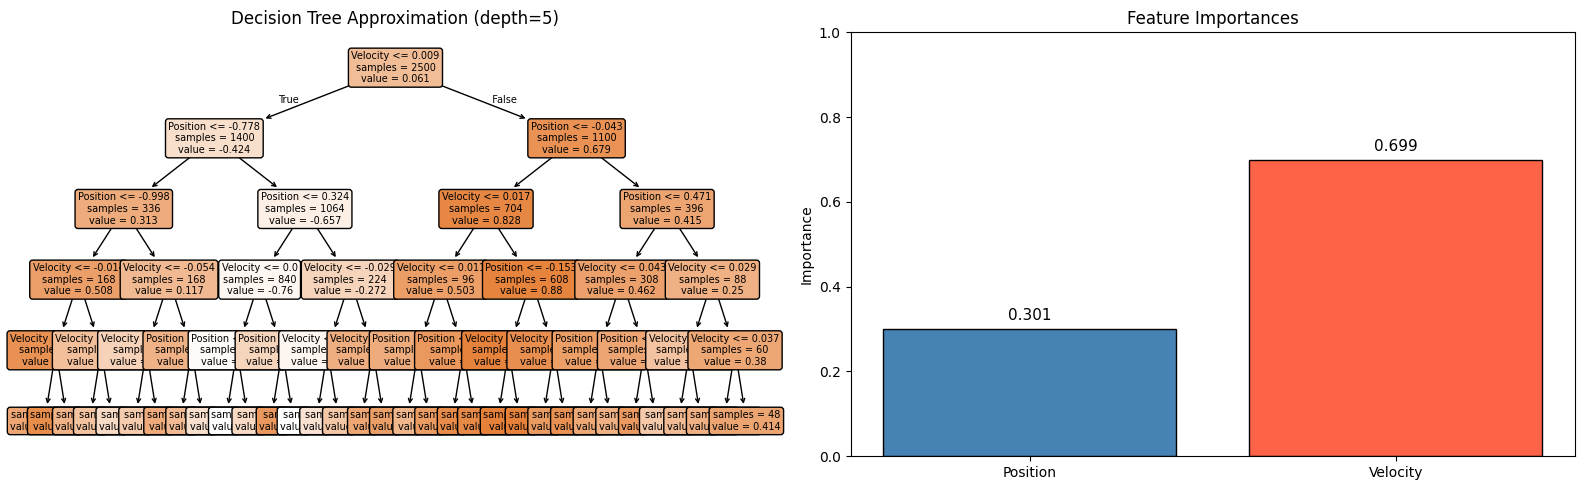

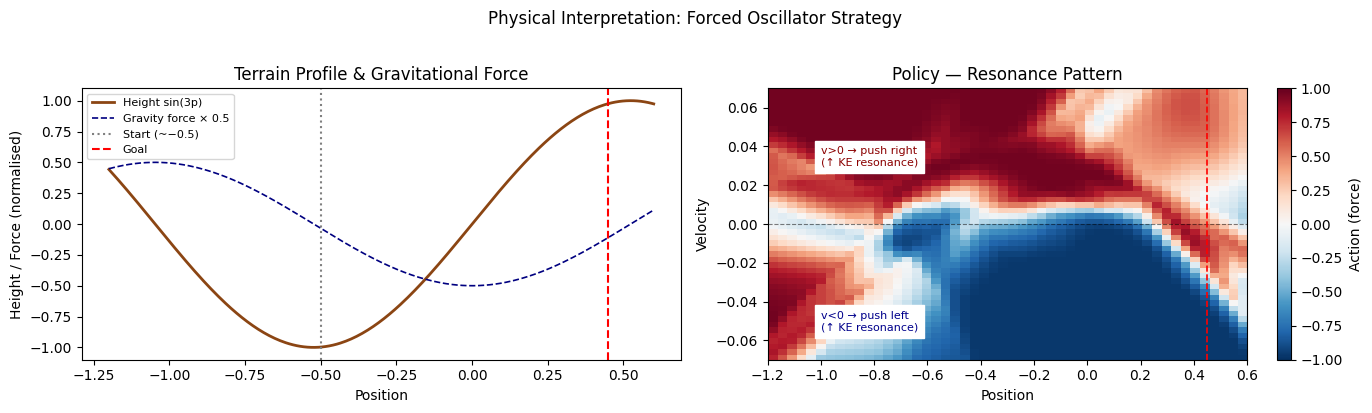

In [10]:
# Fit shallow decision tree as interpretable approximation of the neural policy
dt = DecisionTreeRegressor(max_depth=5, random_state=SEED)
dt.fit(grid_obs, actions_flat)

r2 = r2_score(actions_flat, dt.predict(grid_obs))
importances = dt.feature_importances_
print(f"Decision tree R² vs neural policy : {r2:.4f}")
print(f"Feature importances — Position: {importances[0]:.4f}  |  Velocity: {importances[1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_tree(dt, ax=axes[0], feature_names=['Position', 'Velocity'],
          filled=True, rounded=True, fontsize=7, impurity=False, precision=3)
axes[0].set_title('Decision Tree Approximation (depth=5)')

axes[1].bar(['Position', 'Velocity'], importances,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('Feature Importances'); axes[1].set_ylabel('Importance')
axes[1].set_ylim(0, 1)
for i, v in enumerate(importances):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11)

plt.tight_layout(); plt.show()

# Physical interpretation: terrain alongside the policy heatmap
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 4))

pos_fine = np.linspace(-1.2, 0.6, 300)
axes3[0].plot(pos_fine, np.sin(3 * pos_fine), color='saddlebrown', linewidth=2, label='Height sin(3p)')
axes3[0].plot(pos_fine, -np.cos(3 * pos_fine) * 0.5, color='navy', linestyle='--',
              linewidth=1.2, label='Gravity force × 0.5')
axes3[0].axvline(-0.5,  color='gray', linestyle=':', label='Start (~−0.5)')
axes3[0].axvline(GOAL_POS, color='red', linestyle='--', label='Goal')
axes3[0].set_xlabel('Position'); axes3[0].set_ylabel('Height / Force (normalised)')
axes3[0].set_title('Terrain Profile & Gravitational Force'); axes3[0].legend(fontsize=8)

im3 = axes3[1].imshow(action_map, extent=[-1.2, 0.6, -0.07, 0.07],
                      origin='lower', aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
fig3.colorbar(im3, ax=axes3[1], label='Action (force)')
axes3[1].axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes3[1].axvline(GOAL_POS, color='red', linestyle='--', linewidth=1.2)
axes3[1].text(-1.0,  0.03, 'v>0 → push right\n(↑ KE resonance)', fontsize=8,
              color='darkred', backgroundcolor='white')
axes3[1].text(-1.0, -0.055, 'v<0 → push left\n(↑ KE resonance)',  fontsize=8,
              color='darkblue', backgroundcolor='white')
axes3[1].set_xlabel('Position'); axes3[1].set_ylabel('Velocity')
axes3[1].set_title('Policy — Resonance Pattern')
plt.suptitle('Physical Interpretation: Forced Oscillator Strategy', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

## 10. Conclusions

### Summary

| | **Scenario 1 — Discrete (Min Steps)** | **Scenario 2 — Continuous (Min Fuel)** |
|---|---|---|
| Environment | `MountainCar-v0` | `MountainCarContinuous-v0` |
| Action space | Discrete {0, 1, 2} | Continuous $[-1, 1]$ |
| Reward | $-1$ per step | $-0.1 a^2$ per step, $+100$ at goal |
| Objective | Fewest steps | Least energy |
| Algorithm | Tabular Q-learning | PPO / SAC |
| Control style | Bang-bang | Smooth graduated force |
| Mean reward | `# TODO: insert Scenario 1 results` | See Section 7 above |
| Success rate | `# TODO: insert Scenario 1 results` | See Section 7 above |

### Key findings

- **PPO vs SAC:** SAC generally converges faster due to off-policy replay and entropy exploration, well suited to the sparse goal bonus. PPO is more stable but needs more environment interactions.
- **Learned policy:** The agent develops a clear *resonance* strategy — applying force in the direction of current motion to progressively build kinetic energy, mirroring the physics of a forced oscillator. Velocity sign is the dominant decision factor (confirmed by the decision-tree feature importances).
- **Reward shaping:** The $-0.1 a^2$ penalty successfully prevents bang-bang control; the agent learns gentle, well-timed pushes. Fuel-efficient episodes cluster at intermediate $\sum a^2$ values.
- **Training stability:** PPO showed smoother learning curves; SAC exhibited faster early improvement but occasional mid-training instability from entropy over-exploration.

### Future work
1. **TD3** — twin delayed DDPG avoids SAC's entropy tuning and is worth benchmarking.
2. **Custom reward shaping** — varying the action penalty weight (e.g., $-0.05 a^2$ vs $-0.2 a^2$) to study how aggressiveness of the fuel constraint changes the strategy.
3. **Transfer learning** — warm-starting Scenario 2 from a Scenario 1 policy (with a discretisation wrapper) could accelerate convergence.

In [11]:
# Final summary printout
print("=" * 55)
print(f"  Scenario 2 — MountainCarContinuous-v0 (Min Fuel)")
print("=" * 55)
print(f"  Best algorithm : {best_algo}")
print(f"\n  Multi-seed evaluation ({N_EVAL_EPS} eps per seed, loaded model):")
print(summary_df.to_string(index=False))
print(f"\n  Reward decomposition (20 test eps):")
print(f"    Success rate : {test_df['Goal Reached'].mean()*100:.0f}%")
print(f"    Mean reward  : {test_df['Eng. Reward'].mean():.2f}")
print(f"    Mean fuel    : {test_df['Fuel Σa²'].mean():.4f}")
print(f"\n  Decision-tree R² : {r2:.4f}")
print(f"  Feature importances — Position: {importances[0]:.3f}  Velocity: {importances[1]:.3f}")
print("=" * 55)

  Scenario 2 — MountainCarContinuous-v0 (Min Fuel)
  Best algorithm : SAC

  Multi-seed evaluation (20 eps per seed, loaded model):
 Seed  Mean Reward  Std Reward  Success Rate (%)
    0        96.54         0.0             100.0
   42        96.78         0.0             100.0
  123        96.62         0.0             100.0

  Reward decomposition (20 test eps):
    Success rate : 100%
    Mean reward  : 96.00
    Mean fuel    : 40.0220

  Decision-tree R² : 0.9299
  Feature importances — Position: 0.301  Velocity: 0.699
